# Linear Probe for Axis Ratio (b/a) Regression

This notebook evaluates AstroDINO embeddings for predicting galaxy axis ratio (inclination).

1. Check axis ratio distribution
2. Linear probe regression on embeddings
3. Embedding visualization (PCA, t-SNE, UMAP) color-coded by axis ratio

In [1]:
import os
import sys
import glob
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from omegaconf import OmegaConf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

PROJECT_ROOT = "/u/yacheng/projects/ssl_outthere"
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "encoder_image/astrodino/benchmark/linearprobe"))

from dinov2.eval.setup import build_model_for_eval
from encoder_image.astrodino.train.data.augmentations import ToRGB

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


Using device: cuda:0


## 0. Configuration

In [2]:
# Model config
MODEL_CONFIG = "/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/config.yaml"
MODEL_WEIGHTS = "/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/eval/training_149999/teacher_checkpoint.pth"
DATA_ROOT = "/u/yacheng/projects/ssl_outthere/images/jwst/f150w"

BATCH_SIZE = 64
MAX_SAMPLES = 20000  # Set to -1 for all samples
SEED = 42

## 1. Check Axis Ratio Distribution

In [3]:
# Load axis_ratio from all h5 files with optional error-based selection
h5_files = sorted(glob.glob(os.path.join(DATA_ROOT, "*.h5")))
print(f"Found {len(h5_files)} h5 files")

# Set an error threshold for selection. Set to None to disable error-based filtering.
AXIS_RATIO_ERR_THRESH = 0.001  # adjust as needed (e.g., 0.05, 0.1)

all_axis_ratios = []
for fpath in tqdm(h5_files, desc="Loading axis_ratio"):
    with h5py.File(fpath, 'r') as f:
        if 'axis_ratio' in f:
            ar = f['axis_ratio'][:]

            # Try to find a matching error dataset
            ar_err = None
            if 'axis_ratio_err' in f:
                ar_err = f['axis_ratio_err'][:]
            elif 'axis_ratio_error' in f:
                ar_err = f['axis_ratio_error'][:]

            # Build mask: finite axis_ratio, and optional finite & thresholded error
            mask = np.isfinite(ar)
            if ar_err is not None:
                mask = mask & np.isfinite(ar_err)
                if AXIS_RATIO_ERR_THRESH is not None:
                    mask = mask & (ar_err <= AXIS_RATIO_ERR_THRESH)

            valid = ar[mask]
            all_axis_ratios.append(valid)

if len(all_axis_ratios) > 0:
    axis_ratios = np.concatenate(all_axis_ratios)
else:
    axis_ratios = np.array([])

print(f"\nTotal samples with valid axis_ratio (after _err filtering): {len(axis_ratios)}")
if len(axis_ratios) > 0:
    print(f"Range: [{axis_ratios.min():.4f}, {axis_ratios.max():.4f}]")
    print(f"Mean: {axis_ratios.mean():.4f}, Std: {axis_ratios.std():.4f}")
    print(f"Median: {np.median(axis_ratios):.4f}")
else:
    print("No valid axis_ratio samples found with current selection criteria.")

Found 20 h5 files


Loading axis_ratio: 100%|██████████| 20/20 [00:02<00:00,  6.91it/s]


Total samples with valid axis_ratio (after _err filtering): 9965
Range: [0.0000, 1.0000]
Mean: 0.4630, Std: 0.3631
Median: 0.3821


## 2. Dataset Class for Axis Ratio

In [9]:
class JWSTAxisRatioDataset(Dataset):
    """JWST dataset for axis ratio regression."""
    
    def __init__(self, root: str, crop_size: int = 64, max_samples: int = -1, seed: int = 42, error_thresh = AXIS_RATIO_ERR_THRESH):
        self.crop_size = crop_size
        self.to_rgb = ToRGB()
        self.center_crop = transforms.CenterCrop(crop_size)
        self.rng = np.random.default_rng(seed=seed)
        self.error_thresh = error_thresh
        # Load h5 files with axis_ratio
        self._files = []
        h5_files = sorted(glob.glob(os.path.join(root, "*.h5")))
        
        for fpath in h5_files:
            try:
                f = h5py.File(fpath, 'r')
                if 'axis_ratio' in f:
                    self._files.append(f)
            except Exception as e:
                print(f"Error: {e}")
        
        print(f"Loaded {len(self._files)} files with axis_ratio")
        
        # Build index of valid samples
        self._valid_indices = []  # (file_idx, local_idx, axis_ratio)
        
        for file_idx, f in enumerate(tqdm(self._files, desc="Indexing")):
            axis_ratio = f['axis_ratio'][:]
            # Attempt to load an associated error array (common names)
            ar_err = None
            if 'axis_ratio_err' in f:
                ar_err = f['axis_ratio_err'][:]
            elif 'axis_ratio_error' in f:
                ar_err = f['axis_ratio_error'][:]

            # Build mask: require finite axis_ratio; if error array present, require finite error
            valid_mask = np.isfinite(axis_ratio)
            valid_mask = valid_mask & np.isfinite(ar_err)
            if AXIS_RATIO_ERR_THRESH != -1:
                valid_mask = valid_mask & (ar_err <= self.error_thresh) & (axis_ratio > 0.01) & (axis_ratio <0.99)


            valid_local_indices = np.where(valid_mask)[0]
            for local_idx in valid_local_indices:
                ar = float(axis_ratio[local_idx])
                self._valid_indices.append((file_idx, local_idx, ar))
        
        print(f"Total valid samples: {len(self._valid_indices)}")
        
        # Subsample if needed
        if max_samples > 0 and max_samples < len(self._valid_indices):
            indices = self.rng.choice(len(self._valid_indices), size=max_samples, replace=False)
            self._valid_indices = [self._valid_indices[i] for i in indices]
            print(f"Subsampled to {len(self._valid_indices)} samples")
    
    def __len__(self):
        return len(self._valid_indices)
    
    def __getitem__(self, index):
        file_idx, local_idx, axis_ratio = self._valid_indices[index]
        
        img = self._files[file_idx]['image'][local_idx].astype('float32')
        img = np.repeat(img[np.newaxis, :, :], 3, axis=0)
        tensor = torch.from_numpy(img)
        tensor = self.center_crop(tensor)
        tensor = torch.from_numpy(self.to_rgb(tensor.numpy()))
        
        return tensor, torch.tensor(axis_ratio, dtype=torch.float32)

## 3. Load Model and Compute Embeddings

In [10]:
# Load model
print("Loading model...")
cfg = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE)
model.eval()
print(f"Model loaded, crop_size={cfg.crops.global_crops_size}")

Loading model...
Model loaded, crop_size=64


In [11]:
# Create dataset
dataset = JWSTAxisRatioDataset(
    DATA_ROOT,
    crop_size=cfg.crops.global_crops_size,
    max_samples=300000,
    seed=SEED,
    error_thresh = 0.001
)
print(f"Dataset size: {len(dataset)}")

Loaded 20 files with axis_ratio


Indexing: 100%|██████████| 20/20 [00:00<00:00, 800.75it/s]

Total valid samples: 6006
Dataset size: 6006


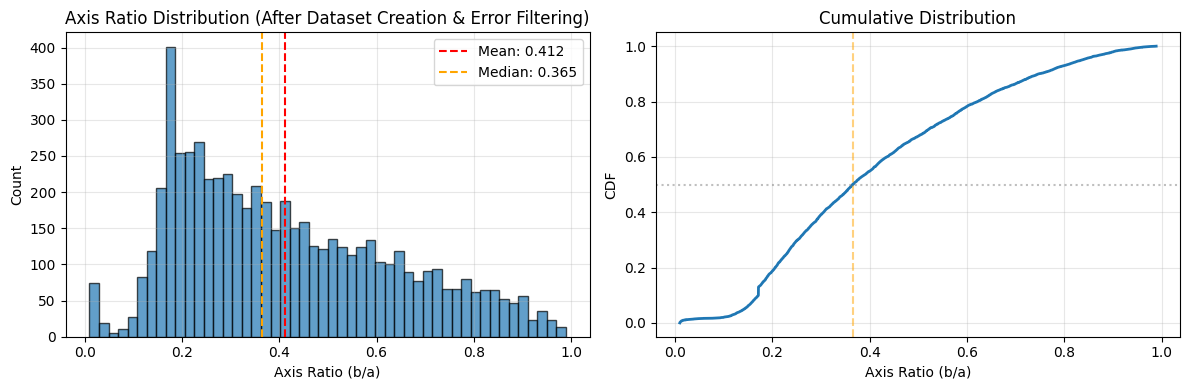


Axis Ratio Statistics (after error filtering):
  Count: 6006
  Mean: 0.4125
  Median: 0.3652
  Std: 0.2217


In [12]:
# Plot axis ratio distribution from dataset
# Extract axis ratios from dataset._valid_indices
axis_ratios_dataset = np.array([pair[2] for pair in dataset._valid_indices])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
ax.hist(axis_ratios_dataset, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(axis_ratios_dataset.mean(), color='red', linestyle='--', label=f'Mean: {axis_ratios_dataset.mean():.3f}')
ax.axvline(np.median(axis_ratios_dataset), color='orange', linestyle='--', label=f'Median: {np.median(axis_ratios_dataset):.3f}')
ax.set_xlabel('Axis Ratio (b/a)')
ax.set_ylabel('Count')
ax.set_title('Axis Ratio Distribution (After Dataset Creation & Error Filtering)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative distribution
ax = axes[1]
sorted_ar = np.sort(axis_ratios_dataset)
cdf = np.arange(1, len(sorted_ar) + 1) / len(sorted_ar)
ax.plot(sorted_ar, cdf, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(np.median(axis_ratios_dataset), color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Axis Ratio (b/a)')
ax.set_ylabel('CDF')
ax.set_title('Cumulative Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAxis Ratio Statistics (after error filtering):")
print(f"  Count: {len(axis_ratios_dataset)}")
print(f"  Mean: {axis_ratios_dataset.mean():.4f}")
print(f"  Median: {np.median(axis_ratios_dataset):.4f}")
print(f"  Std: {axis_ratios_dataset.std():.4f}")

In [13]:
# Compute embeddings
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

all_embeddings = []
all_targets = []

with torch.no_grad():
    for batch_imgs, batch_targets in tqdm(dataloader, desc="Computing embeddings"):
        batch_imgs = batch_imgs.to(DEVICE)
        emb = model(batch_imgs)
        if isinstance(emb, tuple):
            emb = emb[0]
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        all_embeddings.append(emb.cpu().numpy())
        all_targets.append(batch_targets.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
targets = np.concatenate(all_targets, axis=0)


print(f"Embeddings shape: {embeddings.shape}")
print(f"Targets shape: {targets.shape}")
print(f"Target range: [{targets.min():.4f}, {targets.max():.4f}]")

Computing embeddings: 100%|██████████| 94/94 [00:40<00:00,  2.33it/s]

Embeddings shape: (6006, 768)
Targets shape: (6006,)
Target range: [0.0100, 0.9890]


## 4. Linear Probe Regression

In [14]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, targets, test_size=0.2, random_state=SEED
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

Train: 4804, Test: 1202


In [15]:
# Linear regressor
class LinearRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)
    
    def forward(self, x):
        return self.fc(x)

in_dim = X_train.shape[1]
regressor = LinearRegressor(in_dim).to(DEVICE)
optimizer = torch.optim.Adam(regressor.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

print(f"Linear Regressor: input_dim={in_dim}")

Linear Regressor: input_dim=768


In [16]:
# Training
num_epochs = 50
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    # Train
    regressor.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = regressor(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(x)
    train_loss /= len(X_train)
    
    # Test
    regressor.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = regressor(x)
            test_loss += loss_fn(pred, y).item() * len(x)
    test_loss /= len(X_test)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {train_loss:.6f}, Test MSE: {test_loss:.6f}")

print(f"\nFinal Test MSE: {test_losses[-1]:.6f}")
print(f"Final Test RMSE: {np.sqrt(test_losses[-1]):.6f}")

Epoch 10/50 - Train MSE: 0.008726, Test MSE: 0.010778
Epoch 20/50 - Train MSE: 0.007553, Test MSE: 0.008810
Epoch 30/50 - Train MSE: 0.006734, Test MSE: 0.008149
Epoch 40/50 - Train MSE: 0.006751, Test MSE: 0.008945
Epoch 50/50 - Train MSE: 0.006179, Test MSE: 0.008173

Final Test MSE: 0.008173
Final Test RMSE: 0.090405


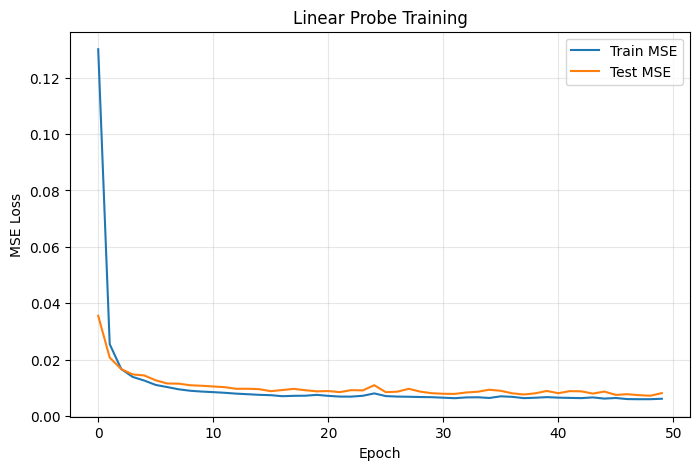

In [17]:
# Plot training curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train MSE')
ax.plot(test_losses, label='Test MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Linear Probe Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

R² Score: 0.8328
MAE: 0.0650
RMSE: 0.0904


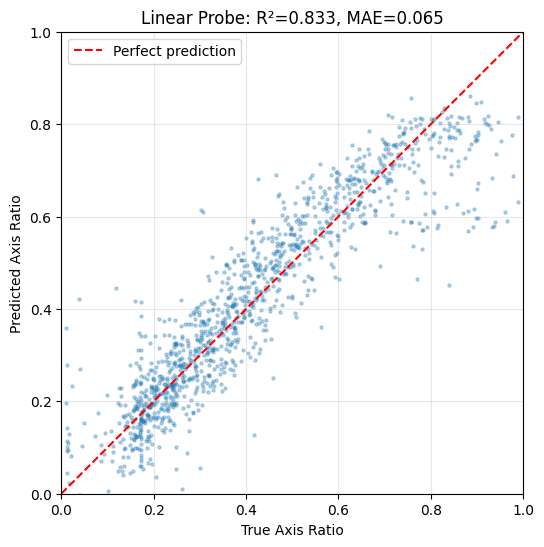

In [18]:
# Predictions vs Ground Truth
regressor.eval()
with torch.no_grad():
    y_pred = regressor(X_test_t.to(DEVICE)).cpu().numpy().flatten()

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=5)
ax.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
ax.set_xlabel('True Axis Ratio')
ax.set_ylabel('Predicted Axis Ratio')
ax.set_title(f'Linear Probe: R²={r2:.3f}, MAE={mae:.3f}')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.show()

## 5. Embedding Visualization (PCA, t-SNE, UMAP)

In [19]:
# Subsample for visualization
n_vis = min(50000, len(embeddings))
vis_idx = np.random.default_rng(SEED).choice(len(embeddings), size=n_vis, replace=False)
emb_vis = embeddings[vis_idx]
targets_vis = targets[vis_idx]

print(f"Visualization samples: {n_vis}")

Visualization samples: 6006


In [20]:
# PCA
print("Running PCA...")
pca = PCA(n_components=50)
emb_pca = pca.fit_transform(emb_vis)
print(f"Explained variance (top 50): {pca.explained_variance_ratio_.sum():.2%}")

Running PCA...
Explained variance (top 50): 91.87%


In [21]:
# t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000, verbose=1)
emb_tsne = tsne.fit_transform(emb_pca)

Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6006 samples in 0.001s...
[t-SNE] Computed neighbors for 6006 samples in 0.840s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6006
[t-SNE] Computed conditional probabilities for sample 2000 / 6006
[t-SNE] Computed conditional probabilities for sample 3000 / 6006
[t-SNE] Computed conditional probabilities for sample 4000 / 6006
[t-SNE] Computed conditional probabilities for sample 5000 / 6006
[t-SNE] Computed conditional probabilities for sample 6000 / 6006
[t-SNE] Computed conditional probabilities for sample 6006 / 6006
[t-SNE] Mean sigma: 3.398823
[t-SNE] KL divergence after 250 iterations with early exaggeration: 78.573486
[t-SNE] KL divergence after 1000 iterations: 1.494437


In [22]:
# UMAP
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED, verbose=True)
emb_umap = reducer.fit_transform(emb_pca)
print("UMAP done.")

Running UMAP...
UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Feb 19 09:19:47 2026 Construct fuzzy simplicial set
Thu Feb 19 09:19:47 2026 Finding Nearest Neighbors
Thu Feb 19 09:19:47 2026 Building RP forest with 9 trees


/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Thu Feb 19 09:19:52 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Thu Feb 19 09:19:59 2026 Finished Nearest Neighbor Search
Thu Feb 19 09:20:02 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Feb 19 09:20:09 2026 Finished embedding
UMAP done.


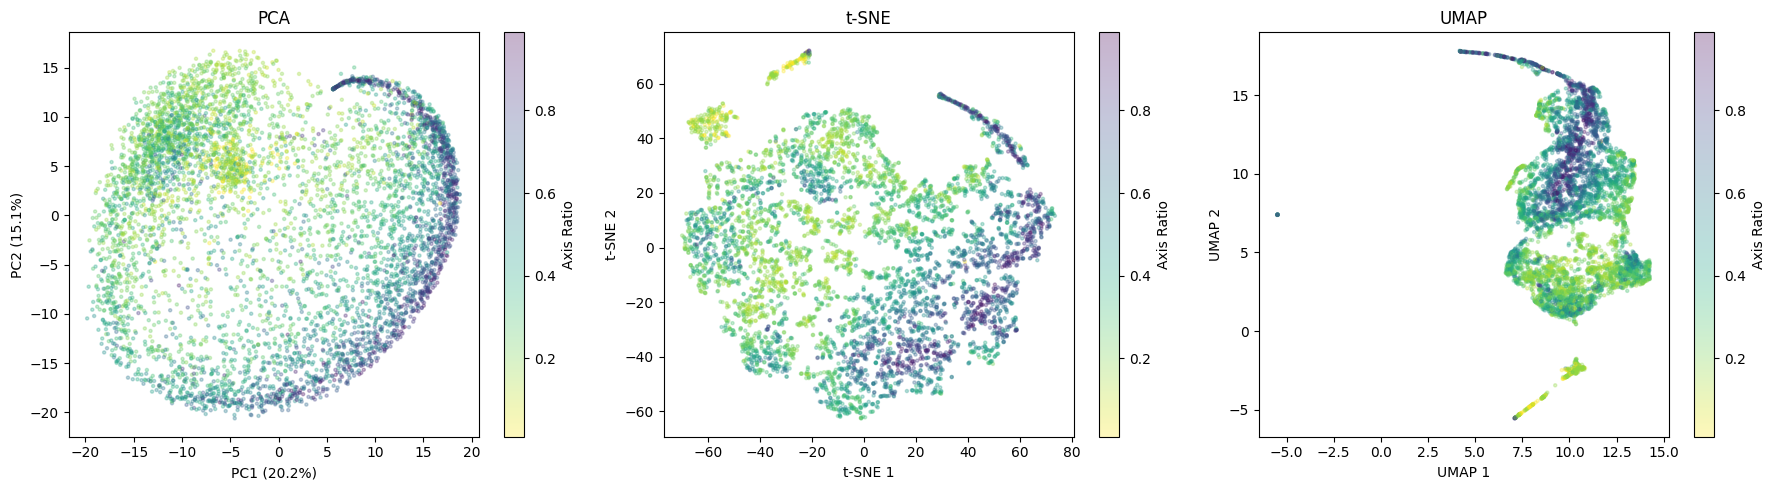

In [23]:
# Plot all three, color-coded by axis ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
ax = axes[0]
sc = ax.scatter(emb_pca[:, 0], emb_pca[:, 1], c=targets_vis, cmap='viridis_r', s=5, alpha=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA')
plt.colorbar(sc, ax=ax, label='Axis Ratio')

# t-SNE
ax = axes[1]
sc = ax.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=targets_vis, cmap='viridis_r', s=5, alpha=0.3)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE')
plt.colorbar(sc, ax=ax, label='Axis Ratio')

# UMAP
ax = axes[2]
sc = ax.scatter(emb_umap[:, 0], emb_umap[:, 1], c=targets_vis, cmap='viridis_r', s=5, alpha=0.3)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP')
plt.colorbar(sc, ax=ax, label='Axis Ratio')

plt.tight_layout()
plt.show()

## 6. Summary

In [247]:
print("=" * 60)
print("AXIS RATIO LINEAR PROBE SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(dataset)} samples")
print(f"Embedding dim: {in_dim}")
print(f"\nLinear Probe Results:")
print(f"  R² Score: {r2:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"\nInterpretation:")
if r2 > 0.5:
    print("  ✅ Strong linear relationship between embeddings and axis ratio")
elif r2 > 0.2:
    print("  ⚠️ Moderate linear relationship")
else:
    print("  ❌ Weak linear relationship - axis ratio may not be well captured")
print("=" * 60)

AXIS RATIO LINEAR PROBE SUMMARY

Dataset: 6008 samples
Embedding dim: 768

Linear Probe Results:
  R² Score: 0.8682
  MAE: 0.0606
  RMSE: 0.0821

Interpretation:
  ✅ Strong linear relationship between embeddings and axis ratio
